# Train WF and ACG Beta-VAEs

End-to-end training of the two autoencoders used for dimensionality reduction
before cell-type classification.

| Model | Input | Latent |
|-------|-------|--------|
| WFConvVAE  | (B, 1, 8, 81)   | 10-dim |
| ACGConvVAE | (B, 1, 10, 101) | 10-dim |

Architecture follows **Beau, Herzfeld, Naveros et al., Cell 2025** (NeuroPyxels).

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path

# ── make the package importable when running from the notebooks/ dir ──────────
# notebooks/ → cerebellum_cell_classifier/ → C:\Users\lidor  (package parent)
pkg_parent = Path().resolve().parent.parent
if str(pkg_parent) not in sys.path:
    sys.path.insert(0, str(pkg_parent))

import numpy as np
import matplotlib.pyplot as plt
import torch

from cerebellum_cell_classifier.autoencoders.models import WFConvVAE, ACGConvVAE
from cerebellum_cell_classifier.autoencoders.train  import train_vae

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.5.1+cu121
CUDA available: True


## 1 — Point to your dataset folder

Set `DATASET_DIR` to the parent folder — all `.npz` files found recursively will be used for training.

In [ ]:
DATASET_DIR    = Path(r"Z:\loco\cell_class\datasets")
CHECKPOINT_DIR = Path("../checkpoints")

# How many waveform channels to use (None = all 8).
# Channels are ordered by proximity to the main channel (index 0 = main).
N_CHAN_USE = 6   # e.g. set to 4 to use only the 4 closest channels

NPZ_PATHS = sorted(DATASET_DIR.rglob("*.npz"))
print(f"Found {len(NPZ_PATHS)} NPZ files:")
for p in NPZ_PATHS:
    npz = np.load(p, allow_pickle=True)
    print(f"  {p.relative_to(DATASET_DIR)}  —  {npz['mean_waveforms'].shape[0]} units")

Found 28 NPZ files:
  AA11_01\AA11_01_features.npz  —  168 units
  AA11_02\AA11_02_features.npz  —  214 units
  AA11_08\AA11_08_features.npz  —  122 units
  AA11_10\AA11_10_features.npz  —  187 units
  AA23_01\AA23_01_features.npz  —  240 units
  AA23_02\AA23_02_features.npz  —  151 units
  AA23_03\AA23_03_features.npz  —  146 units
  AA23_05\AA23_05_features.npz  —  148 units
  AA23_07\AA23_07_features.npz  —  167 units
  AA23_11\AA23_11_features.npz  —  262 units
  CB01_04\CB01_04_features.npz  —  269 units
  CB01_05\CB01_05_features.npz  —  273 units
  CB01_06\CB01_06_features.npz  —  259 units
  CB01_08\CB01_08_features.npz  —  280 units
  CB01_09\CB01_09_features.npz  —  305 units
  CB01_11\CB01_11_features.npz  —  289 units
  CB01_12\CB01_12_features.npz  —  262 units
  CB01_13\CB01_13_features.npz  —  287 units
  CB01_14\CB01_14_features.npz  —  237 units
  XG009\XG009_240625_rec1_right_g0_imec0_features.npz  —  223 units
  XG021\XG021_241017_rec1_g0_imec0_features.npz  —  189 u

## 1b — Data quality check\n\nRun this before training to spot outlier units that could corrupt the latent space.

Total units: 5744

── Waveform ──────────────────────────────────
  NaN units        : 0
  Flat (<1 µV)     : 0
  Peak amp  median : 69.4 µV
  Peak amp  p1/p99 : 28.7 / 249.3 µV
  NaN after norm   : 0
  Inf after norm   : 0

── ACG ───────────────────────────────────────
  Silent (<0.5 Hz) : 0
  NaN units        : 0
  Max FR  median   : 40.1 Hz
  Max FR  p1/p99   : 5.3 / 448.8 Hz
  NaN after norm   : 0

── Spike counts ──────────────────────────────
  n_spikes >=  100 : 5744 / 5744
  n_spikes >=  300 : 5742 / 5744
  n_spikes >=  500 : 5732 / 5744
  n_spikes >= 1000 : 5696 / 5744


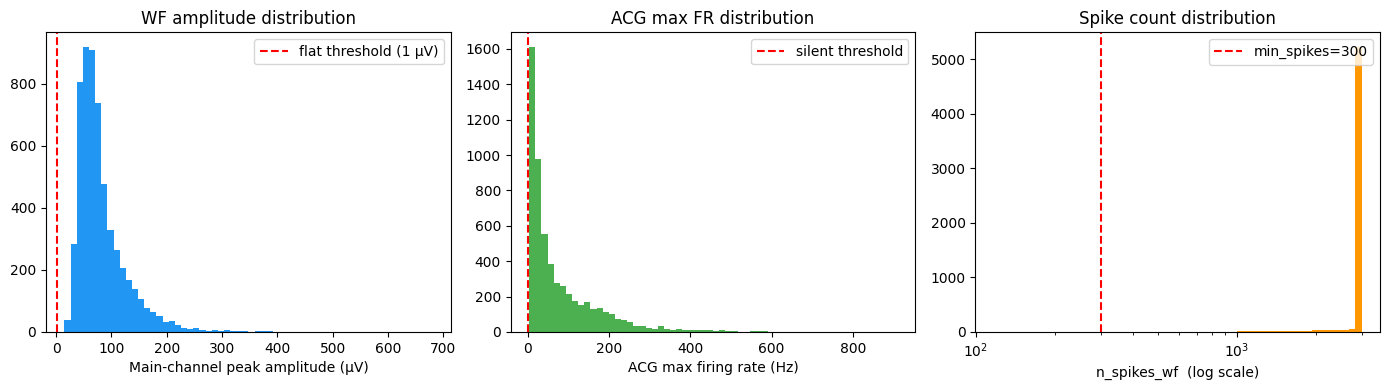


⚠  Units flagged as problematic: 0 / 5744  (0.0%)


In [3]:
from cerebellum_cell_classifier.autoencoders.transforms import normalize_waveforms, normalize_acg3d

# ── Collect raw data across all files ────────────────────────────────────────
all_wf, all_acg, all_spikes = [], [], []
for p in NPZ_PATHS:
    npz = np.load(p, allow_pickle=True)
    all_wf.append(npz["mean_waveforms"].astype(np.float32))
    all_acg.append(npz["acg_3d"].astype(np.float32))
    all_spikes.append(npz["n_spikes_wf"].astype(np.float32))

wf_raw  = np.concatenate(all_wf,     axis=0)   # (N, C, T)
acg_raw = np.concatenate(all_acg,    axis=0)   # (N, 201, 10)
spikes  = np.concatenate(all_spikes, axis=0)   # (N,)
N = len(wf_raw)
print(f"Total units: {N}")

# ── WF diagnostics ───────────────────────────────────────────────────────────
wf_peak_amp = np.abs(wf_raw[:, 0, :]).max(axis=1)
wf_nan      = np.isnan(wf_raw).any(axis=(1, 2))
wf_flat     = wf_peak_amp < 1.0

print(f"\n── Waveform ──────────────────────────────────")
print(f"  NaN units        : {wf_nan.sum()}")
print(f"  Flat (<1 µV)     : {wf_flat.sum()}")
print(f"  Peak amp  median : {np.median(wf_peak_amp):.1f} µV")
print(f"  Peak amp  p1/p99 : {np.percentile(wf_peak_amp,1):.1f} / {np.percentile(wf_peak_amp,99):.1f} µV")
wf_norm = normalize_waveforms(wf_raw)
print(f"  NaN after norm   : {np.isnan(wf_norm).sum()}")
print(f"  Inf after norm   : {np.isinf(wf_norm).sum()}")

# ── ACG diagnostics ──────────────────────────────────────────────────────────
acg_max    = acg_raw.max(axis=(1, 2))
acg_silent = acg_max < 0.5

print(f"\n── ACG ───────────────────────────────────────")
print(f"  Silent (<0.5 Hz) : {acg_silent.sum()}")
print(f"  NaN units        : {np.isnan(acg_raw).any(axis=(1,2)).sum()}")
print(f"  Max FR  median   : {np.median(acg_max):.1f} Hz")
print(f"  Max FR  p1/p99   : {np.percentile(acg_max,1):.1f} / {np.percentile(acg_max,99):.1f} Hz")
acg_norm = normalize_acg3d(acg_raw)
print(f"  NaN after norm   : {np.isnan(acg_norm).sum()}")

# ── Spike count distribution ─────────────────────────────────────────────────
print(f"\n── Spike counts ──────────────────────────────")
for thr in [100, 300, 500, 1000]:
    print(f"  n_spikes >= {thr:4d} : {(spikes >= thr).sum()} / {N}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(wf_peak_amp, bins=60, color="#2196F3", edgecolor="none")
axes[0].axvline(1.0, color="r", ls="--", label="flat threshold (1 µV)")
axes[0].set_xlabel("Main-channel peak amplitude (µV)")
axes[0].set_title("WF amplitude distribution")
axes[0].legend()

axes[1].hist(acg_max, bins=60, color="#4CAF50", edgecolor="none")
axes[1].axvline(0.5, color="r", ls="--", label="silent threshold")
axes[1].set_xlabel("ACG max firing rate (Hz)")
axes[1].set_title("ACG max FR distribution")
axes[1].legend()

# Log-scale x-axis for spike counts (distribution is heavily right-skewed)
axes[2].hist(spikes, bins=np.logspace(np.log10(max(spikes.min(),1)),
                                      np.log10(spikes.max()), 60),
             color="#FF9800", edgecolor="none")
axes[2].axvline(300, color="r", ls="--", label="min_spikes=300")
axes[2].set_xscale("log")
axes[2].set_xlabel("n_spikes_wf  (log scale)")
axes[2].set_title("Spike count distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

bad = wf_flat | wf_nan | acg_silent
print(f"\n⚠  Units flagged as problematic: {bad.sum()} / {N}  ({100*bad.sum()/N:.1f}%)")

## 2 — Train the Waveform Autoencoder

Using **beta=0** (pure autoencoder, no KL regularisation).

Why: the KL term in a beta-VAE causes posterior collapse when the decoder is
powerful enough to reconstruct from an average latent code.  For dimensionality
reduction (t-SNE / PCA) we don't need generation — we need the best possible
reconstruction so the latent space organises by actual waveform shape.

In [4]:
wf_model = WFConvVAE(n_channels=N_CHAN_USE, n_timepoints=81, latent_dim=10)

wf_result = train_vae(
    wf_model,
    NPZ_PATHS,
    model_type       = "wf",
    n_epochs         = 1000,
    batch_size       = 64,
    lr               = 1e-3,
    beta_max         = 0.0,    # pure autoencoder — no KL, no posterior collapse
    beta_anneal      = False,
    patience         = 30,
    min_spikes       = 300,
    n_chan_use       = N_CHAN_USE,
    amplitude_weight = 4.0,
    save_dir         = CHECKPOINT_DIR / "wf",
)

Training on: cuda
WFDataset: 5742 units from 28 file(s).  Sample shape: (1, 8, 81)
Train: 5168 units  |  Val: 574 units
  Epoch   1/1000  beta=0.000  lr=1.00e-03  train=0.0330 (recon=0.0330 kl=1.8522)  val=0.0141 (recon=0.0141 kl=2.7536)  *best*
  Epoch   2/1000  beta=0.000  lr=1.00e-03  train=0.0123 (recon=0.0123 kl=3.4708)  val=0.0097 (recon=0.0097 kl=3.7619)  *best*
  Epoch   3/1000  beta=0.000  lr=1.00e-03  train=0.0093 (recon=0.0093 kl=4.0690)  val=0.0092 (recon=0.0092 kl=4.2726)  *best*
  Epoch   4/1000  beta=0.000  lr=1.00e-03  train=0.0079 (recon=0.0079 kl=4.3512)  val=0.0082 (recon=0.0082 kl=4.5235)  *best*
  Epoch   5/1000  beta=0.000  lr=1.00e-03  train=0.0071 (recon=0.0071 kl=4.6642)  val=0.0076 (recon=0.0076 kl=4.5426)  *best*
  Epoch   6/1000  beta=0.000  lr=1.00e-03  train=0.0067 (recon=0.0067 kl=4.8021)  val=0.0068 (recon=0.0068 kl=4.7416)  *best*
  Epoch   7/1000  beta=0.000  lr=1.00e-03  train=0.0059 (recon=0.0059 kl=4.8912)  val=0.0062 (recon=0.0062 kl=4.8078)  *best

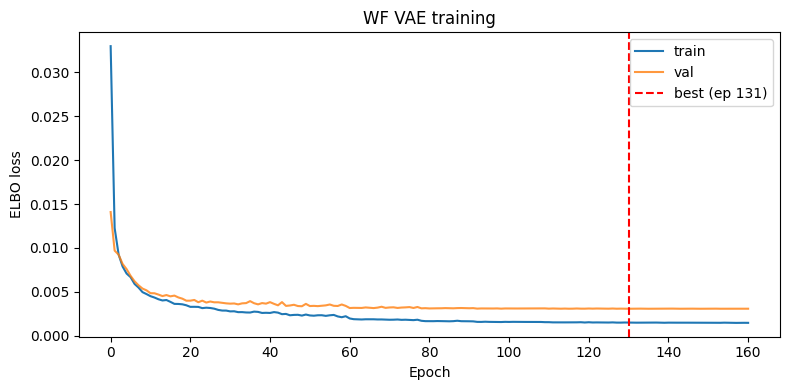

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wf_result["train_losses"], label="train")
ax.plot(wf_result["val_losses"],   label="val", alpha=0.8)
ax.axvline(wf_result["best_epoch"] - 1, color="r", ls="--", label=f'best (ep {wf_result["best_epoch"]})')
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO loss")
ax.set_title("WF VAE training")
ax.legend()
plt.tight_layout()
plt.show()

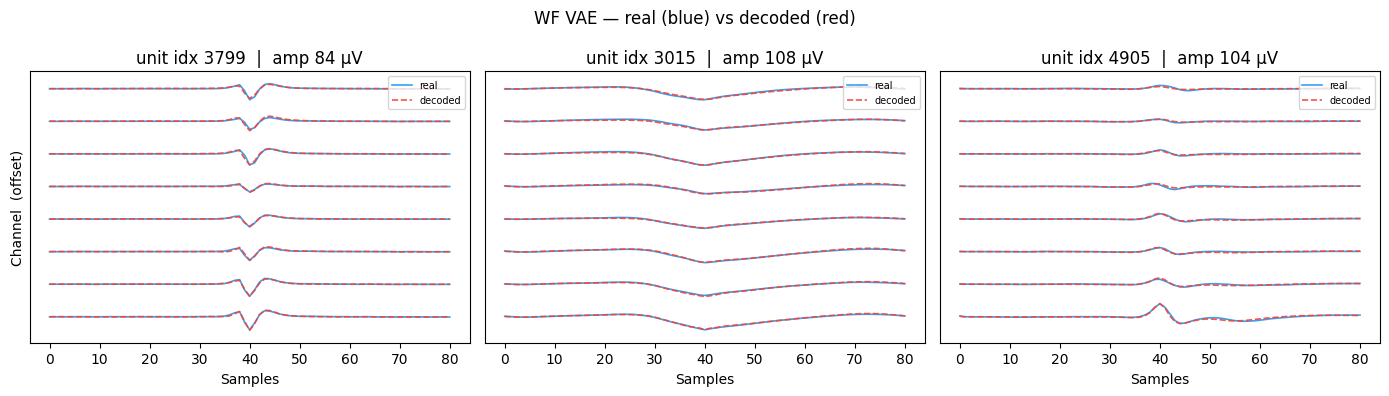

In [6]:
# ── WF reconstruction: 3 random examples (real vs decoded) ───────────────────
dev = next(wf_model.parameters()).device

# pick 3 well-isolated units (high amplitude, enough spikes)
good_idx = np.where((wf_peak_amp >= np.percentile(wf_peak_amp, 50))
                    & (spikes >= 300)
                    & ~wf_nan)[0]
rng      = np.random.default_rng(0)
picks    = rng.choice(good_idx, size=3, replace=False)

wf_model.eval()
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, idx in zip(axes, picks):
    # prepare input
    wf_in = wf_raw[[idx], :N_CHAN_USE, :]               # (1, C, T)
    wf_in = normalize_waveforms(wf_in)
    wf_t  = torch.from_numpy(wf_in[:, np.newaxis]).to(dev)

    with torch.no_grad():
        wf_dec, _, _ = wf_model(wf_t)
    wf_dec = wf_dec.cpu().numpy()[0, 0]                 # (C, T)

    t = np.arange(wf_in.shape[-1])
    for ch in range(wf_in.shape[1]):
        offset = ch * 2.5
        ax.plot(t, wf_in[0, ch] + offset, color="#2196F3", lw=1.2, alpha=0.9,
                label="real" if ch == 0 else None)
        ax.plot(t, wf_dec[ch]  + offset, color="#F44336",  lw=1.2, alpha=0.9,
                ls="--", label="decoded" if ch == 0 else None)

    ax.set_title(f"unit idx {idx}  |  amp {wf_peak_amp[idx]:.0f} µV")
    ax.set_xlabel("Samples")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_yticks([])

axes[0].set_ylabel("Channel  (offset)")
fig.suptitle("WF VAE — real (blue) vs decoded (red)", fontsize=12)
plt.tight_layout()
plt.show()

## 3 — Train the ACG Autoencoder

Also using **beta=0** (pure autoencoder) for the same reason.

In [7]:
acg_model = ACGConvVAE(latent_dim=10, dropout=0.2)

acg_result = train_vae(
    acg_model,
    NPZ_PATHS,
    model_type        = "acg",
    n_epochs          = 1000,
    batch_size        = 32,
    lr                = 5e-4,
    beta_max          = 0.0,   # pure autoencoder
    beta_anneal       = False,
    short_lag_weight  = 1.5,
    n_short           = 20,
    patience          = 30,
    min_spikes        = 300,
    save_dir          = CHECKPOINT_DIR / "acg",
)

Training on: cuda
ACGDataset: 5742 units from 28 file(s).  Sample shape: (1, 10, 101)
Train: 5168 units  |  Val: 574 units
  Epoch   1/1000  beta=0.000  lr=5.00e-04  train=0.0344 (recon=0.0344 kl=1.6296)  val=0.0183 (recon=0.0183 kl=3.0753)  *best*
  Epoch   2/1000  beta=0.000  lr=5.00e-04  train=0.0157 (recon=0.0157 kl=3.4228)  val=0.0126 (recon=0.0126 kl=3.7603)  *best*
  Epoch   3/1000  beta=0.000  lr=5.00e-04  train=0.0136 (recon=0.0136 kl=4.0041)  val=0.0113 (recon=0.0113 kl=3.9830)  *best*
  Epoch   4/1000  beta=0.000  lr=5.00e-04  train=0.0127 (recon=0.0127 kl=4.2612)  val=0.0106 (recon=0.0106 kl=4.2211)  *best*
  Epoch   5/1000  beta=0.000  lr=5.00e-04  train=0.0118 (recon=0.0118 kl=4.5176)  val=0.0101 (recon=0.0101 kl=4.4473)  *best*
  Epoch   6/1000  beta=0.000  lr=5.00e-04  train=0.0111 (recon=0.0111 kl=4.7486)  val=0.0097 (recon=0.0097 kl=4.5775)  *best*
  Epoch   7/1000  beta=0.000  lr=5.00e-04  train=0.0109 (recon=0.0109 kl=4.7918)  val=0.0093 (recon=0.0093 kl=4.7906)  *b

C:\Users\lidor\AppData\Local\Temp\ipykernel_542604\1200210833.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


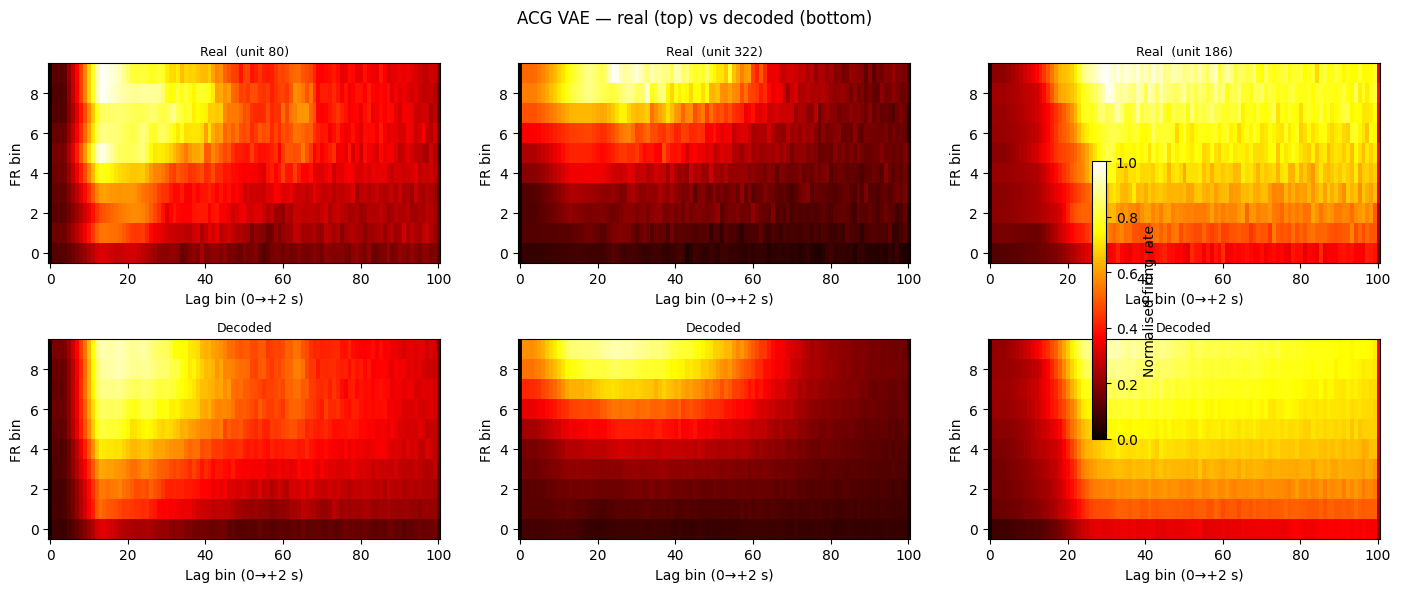

In [8]:
# ── ACG reconstruction: 3 examples, real | decoded side by side ───────────────
dev = next(acg_model.parameters()).device

good_acg_idx = np.where((acg_max >= np.percentile(acg_max, 50))
                        & (spikes >= 300))[0]
picks_acg    = rng.choice(good_acg_idx, size=3, replace=False)

acg_model.eval()
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

# lag axis: 0 → 2000 ms (101 positive bins, originally log-spaced)
t_log_pos = np.arange(101)   # bin indices; label only 0/50/100

for col, idx in enumerate(picks_acg):
    acg_in = acg_raw[[idx]]                             # (1, 201, 10)
    acg_n  = normalize_acg3d(acg_in)                   # (1, 1, 10, 101)
    acg_t  = torch.from_numpy(acg_n).to(dev)

    with torch.no_grad():
        acg_dec, _, _ = acg_model(acg_t)
    acg_dec = acg_dec.cpu().numpy()[0, 0]              # (10, 101)
    acg_real = acg_n[0, 0]                             # (10, 101)

    vmax = max(acg_real.max(), acg_dec.max(), 1e-6)

    im0 = axes[0, col].imshow(acg_real, aspect="auto", origin="lower",
                               vmin=0, vmax=vmax, cmap="hot")
    axes[0, col].set_title(f"Real  (unit {idx})", fontsize=9)

    im1 = axes[1, col].imshow(acg_dec, aspect="auto", origin="lower",
                               vmin=0, vmax=vmax, cmap="hot")
    axes[1, col].set_title("Decoded", fontsize=9)

    for ax in axes[:, col]:
        ax.set_xlabel("Lag bin (0→+2 s)")
        ax.set_ylabel("FR bin")

fig.suptitle("ACG VAE — real (top) vs decoded (bottom)", fontsize=12)
plt.colorbar(im1, ax=axes, shrink=0.6, label="Normalised firing rate")
plt.tight_layout()
plt.show()

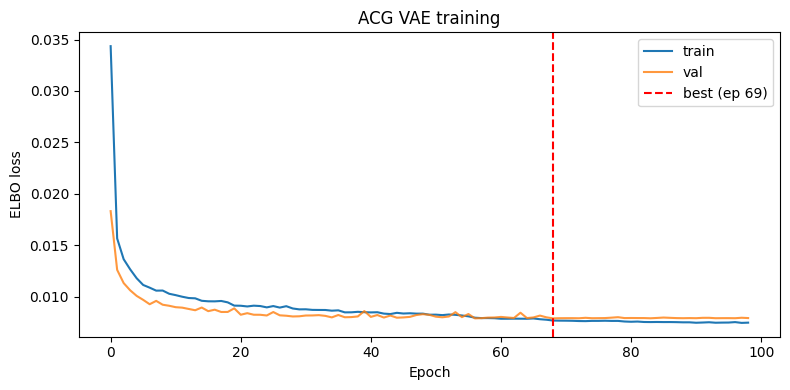

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(acg_result["train_losses"], label="train")
ax.plot(acg_result["val_losses"],   label="val", alpha=0.8)
ax.axvline(acg_result["best_epoch"] - 1, color="r", ls="--", label=f'best (ep {acg_result["best_epoch"]})')
ax.set_xlabel("Epoch")
ax.set_ylabel("ELBO loss")
ax.set_title("ACG VAE training")
ax.legend()
plt.tight_layout()
plt.show()

## 4 — Encode a dataset (inference)

Load the best checkpoint and extract 10-dim latent vectors for every unit in a recording.

In [10]:
import pandas as pd
from cerebellum_cell_classifier.autoencoders.transforms import normalize_waveforms, normalize_acg3d


def _load_c4_labels(npz_path, unit_ids):
    npz_path = Path(npz_path)
    csv_path = npz_path.parent / (npz_path.stem.replace("_features", "_table") + ".csv")
    if not csv_path.exists():
        csv_path = npz_path.parent / (npz_path.stem + ".csv")

    labels = np.array(["unknown"] * len(unit_ids), dtype=object)
    if csv_path.exists() and "C4_predicted_cell_type" in pd.read_csv(csv_path, nrows=0).columns:
        df = pd.read_csv(csv_path)[["unit_id", "C4_predicted_cell_type"]]
        df["C4_predicted_cell_type"] = df["C4_predicted_cell_type"].fillna("unknown").str.strip()
        df["C4_predicted_cell_type"] = df["C4_predicted_cell_type"].replace("", "unknown")
        uid2lbl = dict(zip(df["unit_id"], df["C4_predicted_cell_type"]))
        labels = np.array([uid2lbl.get(uid, "unknown") for uid in unit_ids])
    return labels


def encode_session(npz_path, wf_ckpt, acg_ckpt, n_chan_use=None, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    dev = torch.device(device)

    npz      = np.load(npz_path, allow_pickle=True)
    unit_ids = npz["unit_ids"]

    # ── Waveform ─────────────────────────────────────────────────────────────
    wf = npz["mean_waveforms"].astype(np.float32)
    wf = normalize_waveforms(wf)
    if n_chan_use is not None:
        wf = wf[:, :n_chan_use, :]                  # keep first n_chan_use channels
    wf = wf[:, np.newaxis, :, :]                    # (N, 1, C, T)
    wf_t = torch.from_numpy(wf).to(dev)

    wf_vae = WFConvVAE(n_channels=wf_t.shape[2], n_timepoints=wf_t.shape[3]).to(dev)
    wf_vae.load_state_dict(torch.load(wf_ckpt, map_location=dev))
    wf_vae.eval()
    with torch.no_grad():
        wf_z = wf_vae.encode(wf_t).cpu().numpy()

    # ── ACG ──────────────────────────────────────────────────────────────────
    acg = npz["acg_3d"].astype(np.float32)
    acg = normalize_acg3d(acg)
    acg_t = torch.from_numpy(acg).to(dev)

    acg_vae = ACGConvVAE().to(dev)
    acg_vae.load_state_dict(torch.load(acg_ckpt, map_location=dev))
    acg_vae.eval()
    with torch.no_grad():
        acg_z = acg_vae.encode(acg_t).cpu().numpy()

    labels = _load_c4_labels(npz_path, unit_ids)
    return wf_z, acg_z, labels


# ── encode every session ──────────────────────────────────────────────────────
WF_CKPT  = CHECKPOINT_DIR / "wf"  / "wf_vae_best.pt"
ACG_CKPT = CHECKPOINT_DIR / "acg" / "acg_vae_best.pt"

all_wf_z, all_acg_z, all_labels = [], [], []

for p in NPZ_PATHS:
    wf_z, acg_z, lbl = encode_session(p, WF_CKPT, ACG_CKPT, n_chan_use=N_CHAN_USE)
    all_wf_z.append(wf_z)
    all_acg_z.append(acg_z)
    all_labels.append(lbl)
    print(f"  {Path(p).name}: {len(lbl)} units")

wf_z   = np.concatenate(all_wf_z,   axis=0)
acg_z  = np.concatenate(all_acg_z,  axis=0)
labels = np.concatenate(all_labels, axis=0)

print(f"\nTotal: {len(labels)} units")
for t in np.unique(labels):
    print(f"  {t}: {(labels==t).sum()}")

C:\Users\lidor\AppData\Local\Temp\ipykernel_542604\4247686146.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wf_vae.load_state_dict(torch.load(wf_ckpt, map_location=de

  AA11_01_features.npz: 168 units
  AA11_02_features.npz: 214 units


C:\Users\lidor\AppData\Local\Temp\ipykernel_542604\4247686146.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wf_vae.load_state_dict(torch.load(wf_ckpt, map_location=de

  AA11_08_features.npz: 122 units
  AA11_10_features.npz: 187 units


C:\Users\lidor\AppData\Local\Temp\ipykernel_542604\4247686146.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wf_vae.load_state_dict(torch.load(wf_ckpt, map_location=de

...

  XG031_20250130_Left_rec2_g0_imec0_features.npz: 193 units
  XG032_250304_np_rec2_g0_imec0_features.npz: 160 units


C:\Users\lidor\AppData\Local\Temp\ipykernel_542604\4247686146.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wf_vae.load_state_dict(torch.load(wf_ckpt, map_location=de

  XG032_20250311_rec2_g0_imec0_features.npz: 161 units
  XG037_20250804_4_OF_g0_imec0_features.npz: 120 units


C:\Users\lidor\AppData\Local\Temp\ipykernel_542604\4247686146.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wf_vae.load_state_dict(torch.load(wf_ckpt, map_location=de

  catgt_XG046_20260208_g0_features.npz: 59 units
  catgt_XG048_20260217_all_deep_g0_features.npz: 123 units

Total: 5744 units
  GoC: 234
  MFB: 2351
  MLI: 389
  PkC_cs: 1153
  PkC_ss: 388
  unknown: 1229


### Quick PCA visualisation of the latent spaces

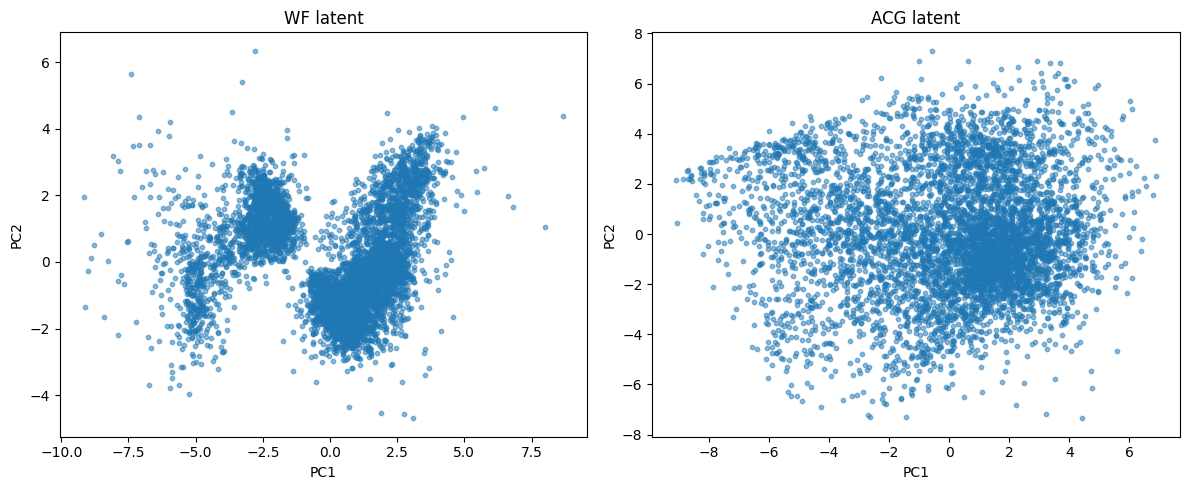

In [11]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, z, title in zip(axes, [wf_z, acg_z], ["WF latent", "ACG latent"]):
    pc = PCA(n_components=2).fit_transform(z)
    ax.scatter(pc[:, 0], pc[:, 1], s=10, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

### t-SNE of the combined 20-dim latent space (WF + ACG), coloured by CCG label

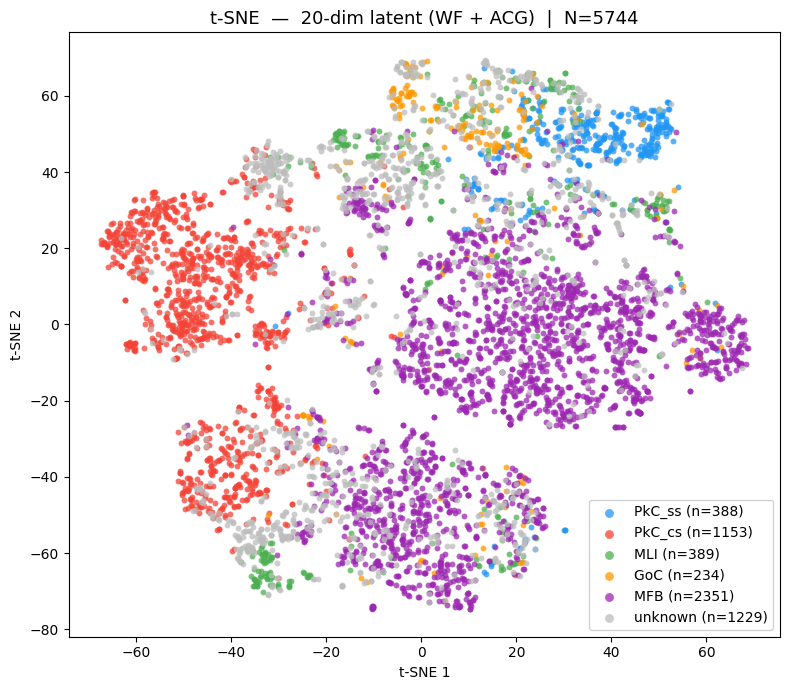

In [12]:
from sklearn.manifold import TSNE

# ── combine the two 10-dim spaces into one 20-dim vector per unit ─────────────
z20 = np.concatenate([wf_z, acg_z], axis=1)   # (N, 20)

# ── t-SNE ────────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=42, init="pca")
z2 = tsne.fit_transform(z20)                   # (N, 2)

# ── colour map (C4 cell types) ────────────────────────────────────────────────
COLORS = {
    "PkC_ss":  "#2196F3",   # blue
    "PkC_cs":  "#F44336",   # red
    "MLI":     "#4CAF50",   # green
    "GoC":     "#FF9800",   # orange
    "MFB":     "#9C27B0",   # purple
    "unknown": "#BDBDBD",   # grey
}

fig, ax = plt.subplots(figsize=(8, 7))

for cell_type, color in COLORS.items():
    mask = labels == cell_type
    if mask.sum() == 0:
        continue
    ax.scatter(
        z2[mask, 0], z2[mask, 1],
        c=color, label=f"{cell_type} (n={mask.sum()})",
        s=18, alpha=0.75, linewidths=0,
    )

ax.set_title(f"t-SNE  —  20-dim latent (WF + ACG)  |  N={len(labels)}", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(framealpha=0.9, markerscale=1.5)
plt.tight_layout()
plt.show()